## **SREINet with incomplete and intermittent noise


## **I. SETUP AND PREPROCESSING**

This section of the code handles the initial setup, data loading, and preprocessing steps required before training the machine learning model. It includes importing necessary Python packages, loading training data, and any preprocessing steps such as data normalization or feature engineering. The code also initializes and configures the hyperparameters necessary for training the machine learning model. 

For this project, I will be approximating the results of the SINDy algorithm using the CombOpnet structure

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from CombOpNet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) > version.parse('2.10.0'):
    print("Error: Tensorflow version is higher than 2.10. Please use Tensorflow 2.10 or lower.")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.10.0              *
*                                            *
**********************************************


### **1.2 Training Data**

Training data is loaded from MATLAB files, including input and output data. The data is then converted into TensorFlow constant tensors for further processing.

#### Create dataset

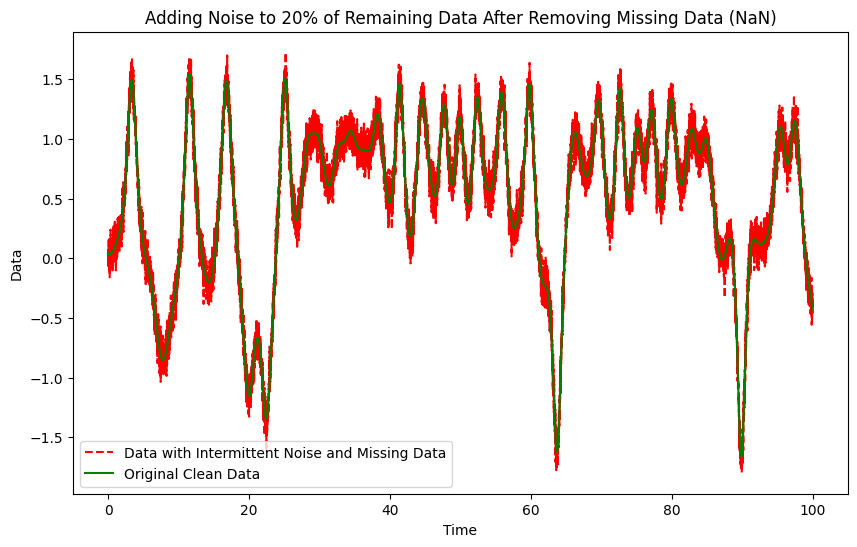

Training input shape: (25000, 20)
Training output shape: (25000, 20)


In [2]:
# Specify the model type
MY_MODEL = 'discrete_phi_quartic' # discrete sine Gordon model 

# Generate data based on the specified model type
node_num = 10
C = 2.0 #coupling strength

#initial conditions for Simulation
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)

#x0 = np.tanh(xn/np.sqrt(1-v**2))  
num_traj = 1 
v = np.linspace(0.0, 0.99, num_traj)
data_initial_conditions= []

for i in range(num_traj):

        x0 = np.random.normal(0, 0.1, size=xn.shape) 
        d_x0 = np.random.normal(0, 0.1, size=xn.shape)  

        new_IC = np.concatenate((x0, d_x0), axis=0) # add velocity
        data_initial_conditions.append(new_IC)



data_T =  250.0       # Length of the data (T)
data_dt = 0.01      # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt)

t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num)


#calcualte the std x_train and dx_train
##print("x_train_std:", np.mean(x_train_std))
#print("dx_train_std:", np.mean(dx_train_std))
import pandas as pd

import numpy as np

# 1. Add intermittent noise to 20% of the data points
noise_percentage = 1.0  # 20% of the data will have noise
noise_level = 0.15  # Noise level (20% of the standard deviation of the data)
missing_percentage = 0.00  # 10% of data will be missing
num_noisy = int(noise_percentage * x_train.shape[0])

# Select random indices from the entire data set to add noise
noisy_indices = np.random.choice(x_train.shape[0], num_noisy, replace=False)

# Generate Gaussian noise (mean=0, std=0.2)
noise_level_x = noise_level * np.std(x_train, axis=0)  # Noise level is 20% of the standard deviation of the data
noise_level_dx = noise_level * np.std(dx_train, axis=0)

noise_x = np.random.normal(0, noise_level_x, size=[num_noisy, x_train.shape[1]])
noise_dx = np.random.normal(0, noise_level_dx, size=[num_noisy, dx_train.shape[1]])

# Add noise to the selected data points
x_data_with_noise = x_train.copy()
x_data_with_noise[noisy_indices, :] += noise_x
dx_data_with_noise = dx_train.copy()
dx_data_with_noise[noisy_indices, :] += noise_dx

# 2. Simulate incomplete data (set some data points to NaN after adding noise)
num_missing = int(missing_percentage * x_data_with_noise.shape[0])
missing_indices = np.random.choice(x_data_with_noise.shape[0], num_missing, replace=False)

# Set the selected indices to NaN
x_data_with_missing = x_data_with_noise.copy()
x_data_with_missing[missing_indices, :] = np.nan
dx_data_with_missing = dx_data_with_noise.copy()
dx_data_with_missing[missing_indices, :] = np.nan

# 3. Interpolate to fill missing (NaN) values using linear interpolation
# For each feature, perform linear interpolation on non-NaN data points
for i in range(x_data_with_missing.shape[1]):
    # Interpolate along each feature axis independently
    x_data_with_missing[:, i] = np.interp(
        np.arange(x_data_with_missing.shape[0]),  # Full index range
        np.where(~np.isnan(x_data_with_missing[:, i]))[0],  # Indices of non-NaN values
        x_data_with_missing[~np.isnan(x_data_with_missing[:, i]), i]  # Non-NaN values
    )
    dx_data_with_missing[:, i] = np.interp(
        np.arange(dx_data_with_missing.shape[0]),
        np.where(~np.isnan(dx_data_with_missing[:, i]))[0],
        dx_data_with_missing[~np.isnan(dx_data_with_missing[:, i]), i]
    )

# Extract final cleaned data
cleaned_x_data = x_data_with_missing
cleaned_dx_data = dx_data_with_missing


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(t_arr[:10000], x_data_with_noise[:10000,0], label='Data with Intermittent Noise and Missing Data', color='red', linestyle='--')
plt.plot(t_arr[:10000], x_train[:10000,0], label='Original Clean Data', color='green')

plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Adding Noise to 20% of Remaining Data After Removing Missing Data (NaN)')
plt.legend()
plt.show()




#plot x_train and dx_train
#import matplotlib.pyplot as plt
#plt.figure(figsize=(10, 6))

#print(x_train.shape)
#plt.plot(t_arr, x_train[:,0])
#plt.show()

#Shuffle data
training_input, training_output = cleaned_x_data, cleaned_dx_data
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)



training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

(25000, 1)
(25000, 10)


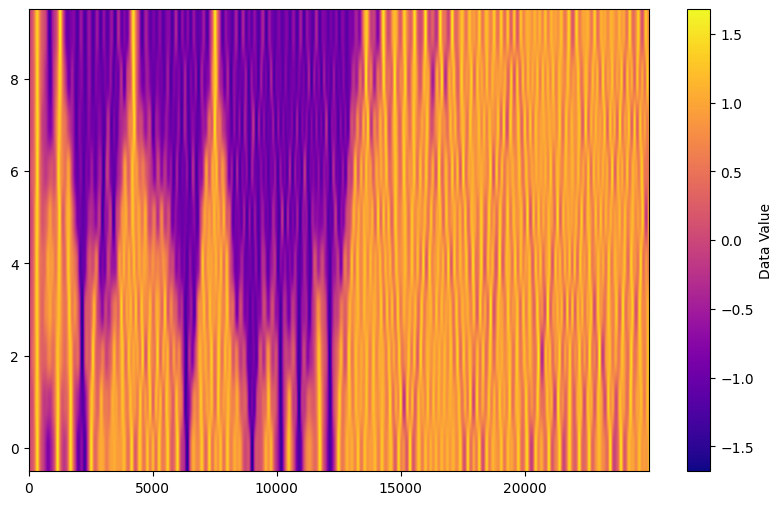

In [3]:
import seaborn as sns

#plot the data of the first set
heatmap_t_arr = t_arr

heatmap_x_train = x_train[:t_arr.shape[0], :node_num]
print(heatmap_t_arr.shape)
print(heatmap_x_train.shape)

#downsample
plt.figure(figsize=(10, 6))
#a1= sns.heatmap(heat_map_dx_train, cmap='viridis', xticklabels=heatmap_t_arr, yticklabels=np.arange(heat_map_dx_train.shape[0]))
#a1.set_xticks([0,2.5, 5, 7.5, 10.])
#plt.imshow(heat_map_dx_train, aspect='auto', cmap='viridis', extent=[heatmap_t_arr[0], heatmap_t_arr[-1], 0, heat_map_dx_train.shape[0]])

import matplotlib.colors as mcolors

plt.imshow(heatmap_x_train.transpose(), aspect='auto', cmap='plasma')

step = 400

plt.colorbar(label='Data Value')
plt.gca().invert_yaxis()

plt.show()

### **1.3 Hyperparameters**

**Hyperparameters** are configuration settings that are external to the model and are not learned from the data during training. Instead, they are set before the training process begins and directly impact the behavior and performance of the model. Examples of hyperparameters include the learning rate, mini-batch size, number of epochs, regularization strength, network architecture, and activation functions.

In [4]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

The data type for computations is set, and the architecture of the neural network is defined. This includes specifying the number of neurons in each layer, the dimensions of the model, and initializing untrainable layers.

**CombOpNet Parameters**

Used to specifly the structure of the neural network

In [5]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * guess_highest_order_polynomial
print(layer_neuron_nums_per_act_fn)

[20, 20, 20]


## **II. Model Training and Execution**

This section of the code contains the implementation of the machine learning model training and evaluation process. After configuring the hyperparameters in the preceding section, this part of the code defines the model architecture, prepares the data, and executes the training process using the specified hyperparameters.

### **2.1 Create the CombOpNet Model**


In [6]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = CombOpNet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4),
                     name='CombOpNet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            model.layers[1].reinitialize_weights()
    else:
        print("CombOpNet does not have a reinitialize_weights() function.")


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


### **2.2 Loss Function**

Loss functions, also known as cost functions, play a crucial role in the training of neural networks. They measure the difference between the predicted outputs of the network and the actual target values. The goal of training is to minimize this loss, which guides the network towards making more accurate predictions.

In [7]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**


An optimizer refers to an algorithm or method used to update the parameters (weights and biases) of the model during the training process. The goal of optimization is to minimize a predefined loss function, which measures the discrepancy between the model's predictions and the actual targets.

In [8]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Training with Pruning**
Gradual pruning is a technique used to reduce the size of a neural network and increase its inference speed without significantly compromising its accuracy. By slowly increasing the sparsity, the network has time to adjust its remaining weights to compensate for the pruned connections, ideally preserving its performance.

**Example Usage**
- **Overview**: The example demonstrates how to integrate the gradual pruning process into a typical training loop of a TensorFlow model.
- **Key Steps**:
  1. A sparsity schedule is initialized using the `gradual_pruning_schedule` function.
  2. For each training step, the current sparsity level is calculated using the schedule.
  3. For each dense layer in the model, a binary mask is created using the `create_binary_mask` function with the current sparsity level.
  4. This mask is applied to the layer's weights using the `prune_weights` function.
  5. The model undergoes a typical training step, including calculating the loss and updating the weights based on gradients. However, here, an additional step involves applying the binary mask to the gradients as well, ensuring that the pruned connections do not contribute to the gradient updates.
  6. Periodically, the script prints the current sparsity level to track the progress of pruning.

### **2.5 Fit_w_pruning**

In [9]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    # Assuming binary_masks_ones is a list of binary masks created for each trainable variable
    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   

def CombOPNet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=0,       # Threshold for early stopping based on training and validation loss
    early_stopping_pruning_threshold=0,    # Threshold for early stopping based on pruning schedule
    verbose=0               # Verbosity mode (0 = silent, 1 = progress bar, etc.)
):
    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def generate_binary_mask_and_prune_weight(model, pruning_weight_threshold):
        binary_masks = []  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started
        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch]
        binary_mask = generate_binary_mask_and_prune_weight(model, current_pruning_threshold)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        #calculate the average of val_loss
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()

        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose:
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            print(f"Epoch {epoch + 1:3.0f}:"
                f"  Train Loss: {current_train_loss:9.4e}"
                f",  Validation Loss: {current_val_loss:9.4e}"
                # f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
                f",  Epoch Time: {epoch_time:.2f}s"  
                f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")    
            
        if model.stop_training: # Stop training if all the layers are untrianable
            break   

        # Check for early stopping
        if current_train_loss < early_stopping_loss_threshold and current_pruning_threshold > early_stopping_pruning_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_val_loss:.4f} is below the threshold {early_stopping_loss_threshold:.4f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

The model is trained using the provided training data, batch size, validation split, number of epochs, callbacks, and optimizer. The training progress is monitored, but verbose output is suppressed to keep the output clean.

#### **Custom Tensorflow Training Loop**

Using the tensorflow steps. This function also includes callback functions

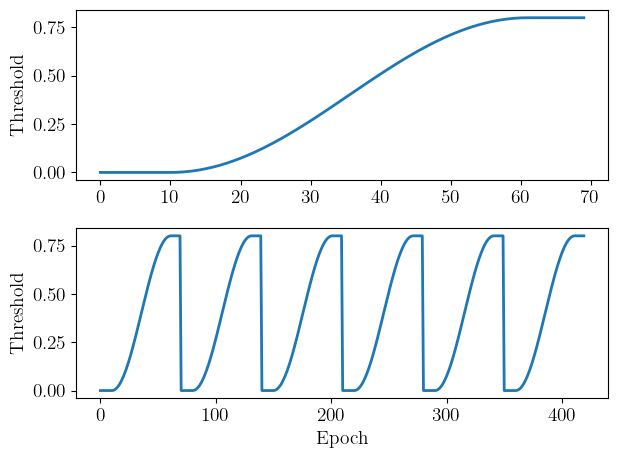

In [10]:
PRUNING_WEIGHT_THRESHOLD = 0.8
N_PERIODS = 6
PRUNING_EPOCHS_PER_PERIOD = 70
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule
pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=PRUNING_WEIGHT_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    zero_percentage=0.15,
                                                    show_plot=True)

In [11]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD =  1.4e-1  # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.6

training_histories = []
weights_list = []
print(f"Data Size: {training_output.shape}")

Data Size: (25000, 20)


In [12]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = CombOPNet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.20,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based)
        verbose=1,                   # Hide the epoch steps
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('CombOpNet').get_weights()])
    #reset the weights


Total Dimensions: 20
Training dimension 1...


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Epoch   1:  Train Loss: 6.2543e-02,  Validation Loss: 2.6424e-02,  Epoch Time: 0.41s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 2.4105e-02,  Validation Loss: 2.1958e-02,  Epoch Time: 0.17s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 2.1266e-02,  Validation Loss: 2.1245e-02,  Epoch Time: 0.19s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 2.1786e-02,  Validation Loss: 2.0215e-02,  Epoch Time: 0.14s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 2.1424e-02,  Validation Loss: 2.0766e-02,  Epoch Time: 0.14s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 2.1581e-02,  Validation Loss: 1.9696e-02,  Epoch Time: 0.16s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 2.2051e-02,  Validation Loss: 2.0435e-02,  Epoch Time: 0.16s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 2.1681e-02,  Validation Loss: 2.0870e-02,  Epoch Time: 0.14s,  Current Pruning Threshold: 0
Epoch   9:  Train Loss: 2.1517e-02,  Validation Loss: 1.9948e-02,  Epoch

## Visualizing weights during training

## **IV. Analysis**

In this section, the code displays the results of the trained machine learning model, including performance metrics, visualizations, and any comparisons to the actual SINDy network or other relevant discussions. It may include visualizations of model predictions, comparisons between predicted and actual values, and discussions on the model's strengths, limitations, and potential areas for improvement. 

### **Coefficient Reconstructor (CombOpNet)**

This function is designed to extract and represent the multiplicative relationships between neurons across layers in a neural network, focusing on the paths that contribute significantly to the network's output.

#### `generate_set_labels`

In [13]:
def generate_set_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`
1. **Input Structure Handling**: The function takes `combopnet_weights`, a nested list that represents the weights of a segmented or parallel neural network (combopnet). This list is structured to encapsulate multiple combopnets, each containing multiple layers, where each layer consists of neurons connected to the next layer through weights.

2. **Unique Prime Number Assignment**:
    - Each neuron in the network is assigned a unique prime number, not based on its layer or combopnet index but purely on its neuron index across the entire network. This assignment is crucial for generating unique keys in the output dictionary, representing different paths through the network.

3. **Path Exploration and Weight Product Calculation**:
    - The function recursively explores all possible paths from the input layer to the output layer across each combopnet.
    - For each path, it calculates two products:
        a. **Prime Product**: The product of the unique prime numbers assigned to each neuron along the path.
        b. **Weight Product**: The product of the weights of connections along the path.

4. **Global Flags and Thresholds**:
    - **ENABLE_MINIMUM_WEIGHT_FILTER**: A flag that, when enabled, allows the function to ignore any path containing a weight below a specified threshold (`MINIMUM_WEIGHT_THRESHOLD`).
    - **MINIMUM_WEIGHT_THRESHOLD**: The minimum weight threshold used to filter paths when `ENABLE_MINIMUM_WEIGHT_FILTER` is enabled.
    - **ENABLE_COEFFICIENT_SORTING**: A flag that, when enabled, sorts the final products within each combopnet based on the absolute value of the weight product, in descending order.

5. **Output Format**:
    - The function outputs a list of dictionaries, one for each combopnet. Each dictionary represents the possible paths through the network:
        - **Keys**: The product of prime numbers representing each neuron along the path. This serves as a unique identifier for the path through the network.
        - **Values**: The product of the weights along the corresponding path.

6. **Recursive Exploration**:
    - A recursive helper function (`explore_path`) is used to traverse the network. This function updates the current product of weights and prime numbers as it progresses from the input layer to the output layer, accumulating results in a list.

7. **Adjustments for Real-World Use Cases**:
    - The function includes placeholders for additional features that might be relevant for certain applications, such as thresholding based on weight magnitudes and sorting the paths based on their significance (as measured by the product of weights).

In [14]:
def coefficient_reconstruction(dim_index,
                               num_activation_fns,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = int((max(max(len(layer) for layer in combopnet) for combopnet in weights) - 1)/num_activation_fns)
    
    labels = generate_set_labels(max_neurons) # number of states = number of neurons - 1

    def explore_path(combopnet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[combopnet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[combopnet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(combopnet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_combopnet_products = []
    for combopnet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[combopnet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(combopnet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        combopnet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in combopnet_products:
                combopnet_products[label_counts_key] += weight_product
            else:
                combopnet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        combopnet_products = {k: v for k, v in combopnet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_combopnet_products = dict(sorted(combopnet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_combopnet_products = combopnet_products

        all_combopnet_products.append(sorted_combopnet_products)

    #output formatting
    labeled_all_combopnet_products = []
    for combopnet_index, sorted_combopnet_products in enumerate(all_combopnet_products):
        combopnet_product_strings = []
        for key, value in sorted_combopnet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if combopnet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            combopnet_product_strings.append(term_str)

        formatted_output = ''.join(combopnet_product_strings)
        layer_prefix = f"(x{combopnet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_combopnet_products.append(full_output)

    return labeled_all_combopnet_products

## **V. Results Display and Discussions**
### **CombOpNet Results**

In [15]:
"""
path_products = coefficient_reconstruction(i,
                                               len(activation_fns),
                                               weights_list[11], 
                                            minimum_coefficient_threshold = 2e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
for index, dimension in enumerate(path_products):
    print(f"{dimension}")
"""

'\npath_products = coefficient_reconstruction(i,\n                                               len(activation_fns),\n                                               weights_list[11], \n                                            minimum_coefficient_threshold = 2e-2,\n                                            coefficient_output_digits = 10, \n                                            enable_coefficient_sorting = False)\n    \nfor index, dimension in enumerate(path_products):\n    print(f"{dimension}")\n'

In [19]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,
                                               len(activation_fns),
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-1,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(x1)'= 0.9619514261*x11
(x2)'= 0.9885487164*x12
(x3)'= 0.9667856769*x13
(x4)'= 0.9866609774*x14
(x5)'= 0.9704641629*x15
(x6)'= 0.9719956504*x16
(x7)'= 0.9771628756*x17
(x8)'= 0.97065953*x18
(x9)'= 0.9750561995*x19
(x10)'= 0.9946159591*x20
(x11)'=  - 1.708620427*x1^3 + 1.657823355*x2
(x12)'= 1.718086988*x1 - 1.743820954*x2 + 1.662895782*x3 - 1.639823109*x2^3
(x13)'= 1.604158732*x2 - 1.67574222*x3 - 1.658971695*x3^3 + 1.647348057*x4
(x14)'= 1.544786542*x3 - 1.735631598*x4 + 1.650026658*x5 - 1.591769009*x4^3
(x15)'= 1.644034183*x4 - 1.729362638*x5 - 1.465979371*x5^3 + 1.620308179*x6
(x16)'= 1.524985902*x5 - 1.649130611*x6 + 1.5485089*x7 - 1.441779254*x6^3
(x17)'= 1.661360603*x6 - 2.964838721*x7 - 1.435709101*x7^2*x8 + 2.57297372*x8
(x18)'= 1.595461778*x7 - 1.773108342*x8 + 1.528940773*x9 - 1.357589734*x8^3
(x19)'= 1.614335043*x8 - 1.75847643*x9 + 1.499039333*x10 - 1.301690706*x9^3
(x20)'= 1.457939343*x9 - 1.451356035*x10^3


In [17]:

import os
import re

opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

# Base filename and file extension for the text file
base_filename = 'output'
file_extension = '.txt'

# Regex pattern to match existing files with the base name and an optional index
pattern = re.compile(rf"{base_filename}(_(\d+))?{file_extension}")

# Initialize the highest index
max_index = -1

# Search for the highest index
for filename in os.listdir(opt_folder):
    match = pattern.match(filename)
    if match:
        # Extract the index from the filename, if present
        index = int(match.group(2)) if match.group(2) else 0
        max_index = max(max_index, index)

# Increment the highest index found
new_index = max_index + 1
if new_index == 0:
    # If no indexed files were found, use the base filename
    file_path = os.path.join(opt_folder, f"{base_filename}_1{file_extension}")
else:
    # If indexed files were found, append the new index to the filename
    file_path = os.path.join(opt_folder, f"{base_filename}_{new_index}{file_extension}")
    


In [18]:
#%%capture captured_output  

with open(file_path, "w") as text_file:
    for i in range(len(weights_list)):
        path_products = coefficient_reconstruction(i,len(activation_fns),
                                                weights_list[i], 
                                                minimum_coefficient_threshold=1e-1,
                                                coefficient_output_digits=10, 
                                                enable_coefficient_sorting=False)
        
        for index, dimension in enumerate(path_products):
            text_file.write(f"{dimension}")
            text_file.write("\n")

# Write the captured output to the dynamically named text file
    #(captured_output.stdout)